# Análisis de importancia de features — TFG ML Lattice Cryptanalysis

## Contexto

Los modelos XGBoost per-dimensión entrenados en `dim_models.ipynb` alcanzan R² > 0.99 para los targets
`target_log_orth_defect` y `target_rhf` en dimensiones d ≥ 80. Este notebook analiza **qué features
explican esa capacidad predictiva** usando dos métodos complementarios:

1. **Importancia de ganancia (built-in XGBoost):** indica cuánto reduce el error de predicción cada feature al dividir nodos. Primera aproximación rápida, aunque puede sobrestimar features continuas de alto rango.
2. **SHAP (SHapley Additive exPlanations, Lundberg & Lee 2017):** cuantifica la contribución marginal de cada feature a cada predicción individual, con garantías teóricas de consistencia y eficiencia. Estándar actual en interpretabilidad de ML en publicaciones académicas.

## Hipótesis a contrastar

**H1 — `target_log_orth_defect`:** Dominan `log|det(B)|` y features de norma (`max ‖bᵢ‖`). El defecto $\delta(B) = \prod_i \|b_i\| / |\det(B)|$ depende directamente del volumen del retículo y de las normas de los vectores base.

**H2 — `target_log_norm_b1`:** `log|det(B)|` domina claramente. La **heurística Gaussiana** predice:

$$\lambda_1(\Lambda) \approx \sqrt{\frac{d}{2\pi e}} \cdot |\det(B)|^{1/d}$$

Para `d` fijo: $\log\|b_1^{\rm red}\| \approx \frac{1}{d}\log|\det(B)| + c(d)$.
El modelo debería *redescubrir* esta relación y asignar casi toda la importancia a `log_det`.

**H3 — `target_rhf`:** Distribución de importancia **más uniforme** entre features. El RHF es:

$$\text{RHF} = \left(\frac{\|b_1^{\rm red}\|}{|\det(B)|^{1/d}}\right)^{1/d}$$

Al dividir por $|\det|^{1/d}$, el término dominante de H2 se cancela. La varianza residual depende de detalles estructurales (`δ`, perfil GSO, tipo de retículo), explicando la mayor dificultad de predicción. Se cuantificará con la entropía de Shannon de la distribución de importancia SHAP.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import warnings
from scipy.stats import entropy as scipy_entropy
from split_utils import reconstruct_base_id, load_test_base_ids

warnings.filterwarnings('ignore', category=UserWarning)
np.random.seed(42)

plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print(f"shap {shap.__version__}")

shap 0.52.0


In [2]:
df = pd.read_csv('lattice_dataset_v2.csv')
# base_id canónico ANTES de get_dummies → se arrastra a df_enc
df['base_id'] = reconstruct_base_id(df)
df_enc = pd.get_dummies(df, columns=['lattice_type'], drop_first=False)

TARGETS = ['target_log_orth_defect', 'target_log_norm_b1', 'target_rhf']
TARGET_LABELS = {
    'target_log_orth_defect': 'log δ(B_red)',
    'target_log_norm_b1':     'log ‖b₁‖',
    'target_rhf':             'RHF',
}

DIMS = sorted(df['d'].unique())
N_SAMPLES = df.groupby('d').size().to_dict()

FEATURE_COLS = [
    'log_det', 'norm_mean', 'norm_std', 'norm_max', 'norm_min', 'norm_ratio',
    'gso_mean', 'gso_std', 'gso_max', 'gso_min', 'gso_ratio', 'gso_slope', 'gso_res_std',
    'log_orth_defect', 'gram_off_diag_mean', 'gram_off_diag_max',
    'log_cond_num', 'mu_mean', 'mu_max', 'mu_frac_gt_05', 'std_B',
    'profile_mass', 'profile_entropy', 'profile_adjacency',
    'delta'
]
lt_cols = [c for c in df_enc.columns if c.startswith('lattice_type_')]
FEAT_COLS_PER_DIM = FEATURE_COLS + lt_cols  # idéntico a dim_models.ipynb

FEAT_LABELS = {
    'log_det':              'log|det(B)|',
    'norm_mean':            'media ‖bᵢ‖',
    'norm_std':             'std ‖bᵢ‖',
    'norm_max':             'max ‖bᵢ‖',
    'norm_min':             'min ‖bᵢ‖',
    'norm_ratio':           'max/min ‖bᵢ‖',
    'gso_mean':             'media ‖bᵢ*‖',
    'gso_std':              'std ‖bᵢ*‖',
    'gso_max':              'max ‖bᵢ*‖',
    'gso_min':              'min ‖bᵢ*‖',
    'gso_ratio':            'max/min ‖bᵢ*‖',
    'gso_slope':            'pendiente GSO',
    'gso_res_std':          'std residuos GSO',
    'log_orth_defect':      'log δ(B) [entrada]',
    'gram_off_diag_mean':   'Gram fuera-diag (media)',
    'gram_off_diag_max':    'Gram fuera-diag (max)',
    'log_cond_num':         'log κ(B)',
    'mu_mean':              'media |μᵢⱼ|',
    'mu_max':               'max |μᵢⱼ|',
    'mu_frac_gt_05':        'frac |μᵢⱼ|>0.5',
    'std_B':                'std(entradas B)',
    'profile_mass':         'masa perfil GSO',
    'profile_entropy':      'entropía perfil GSO',
    'profile_adjacency':    'adyacencia perfil GSO',
    'delta':                'δ (parámetro LLL)',
    'lattice_type_gaussian':'tipo: gaussian',
    'lattice_type_qary':    'tipo: q-ary',
    'lattice_type_sparse':  'tipo: sparse',
    'lattice_type_uniform': 'tipo: uniform',
}

feat_labels_list = [FEAT_LABELS.get(f, f) for f in FEAT_COLS_PER_DIM]
print(f"Dataset: {df.shape[0]} filas, {len(FEAT_COLS_PER_DIM)} features por dimensión")
print(f"Dimensiones: {DIMS}")
print(f"One-hot cols: {lt_cols}")

Dataset: 224000 filas, 29 features por dimensión
Dimensiones: [np.int64(10), np.int64(20), np.int64(30), np.int64(50), np.int64(80), np.int64(100), np.int64(120), np.int64(150), np.int64(200)]
One-hot cols: ['lattice_type_gaussian', 'lattice_type_qary', 'lattice_type_sparse', 'lattice_type_uniform']


---
## 1. Importancia built-in XGBoost (Gain) — Vista rápida

La importancia de **ganancia** (gain) de XGBoost mide la reducción media del error de predicción cuando
un nodo usa esa feature para dividir los datos de entrenamiento. Se normaliza a suma 1 por modelo.

**Limitación conocida:** la ganancia tiende a sobrestimar features continuas de alto rango respecto a
features categóricas o de variación reducida. Por eso se usará SHAP en la sección 2 como análisis principal.

El heatmap muestra el **promedio ponderado** de la importancia de ganancia sobre todas las dimensiones
(peso proporcional al tamaño del conjunto de test de cada dimensión), para las 15 features más relevantes.

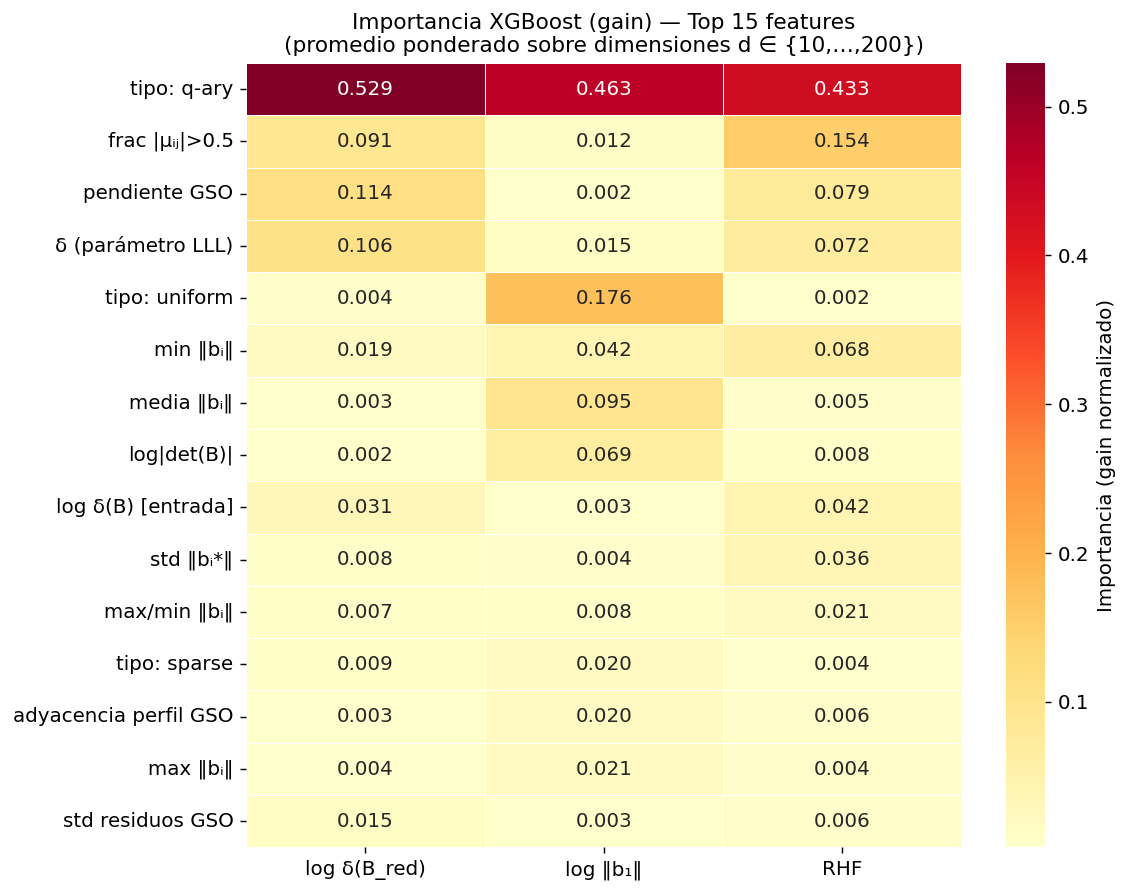

→ graphs/feat_importance_builtin.png


In [3]:
gain_importance = {t: np.zeros(len(FEAT_COLS_PER_DIM)) for t in TARGETS}
total_w = {t: 0.0 for t in TARGETS}

for target in TARGETS:
    for d in DIMS:
        model = joblib.load(f'models/per_dim/gb_{target}_d{d}.pkl')
        w = N_SAMPLES[d] * 0.2
        gain_importance[target] += model.feature_importances_ * w
        total_w[target] += w
    gain_importance[target] /= total_w[target]

gain_df = pd.DataFrame(
    {TARGET_LABELS[t]: gain_importance[t] for t in TARGETS},
    index=feat_labels_list
)
top15_idx = gain_df.mean(axis=1).nlargest(15).index
gain_top = gain_df.loc[top15_idx]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    gain_top, annot=True, fmt='.3f',
    cmap='YlOrRd', linewidths=0.4, ax=ax,
    cbar_kws={'label': 'Importancia (gain normalizado)'}
)
ax.set_title(
    'Importancia XGBoost (gain) — Top 15 features\n'
    '(promedio ponderado sobre dimensiones d ∈ {10,…,200})'
)
plt.tight_layout()
plt.savefig('graphs/feat_importance_builtin.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ graphs/feat_importance_builtin.png')

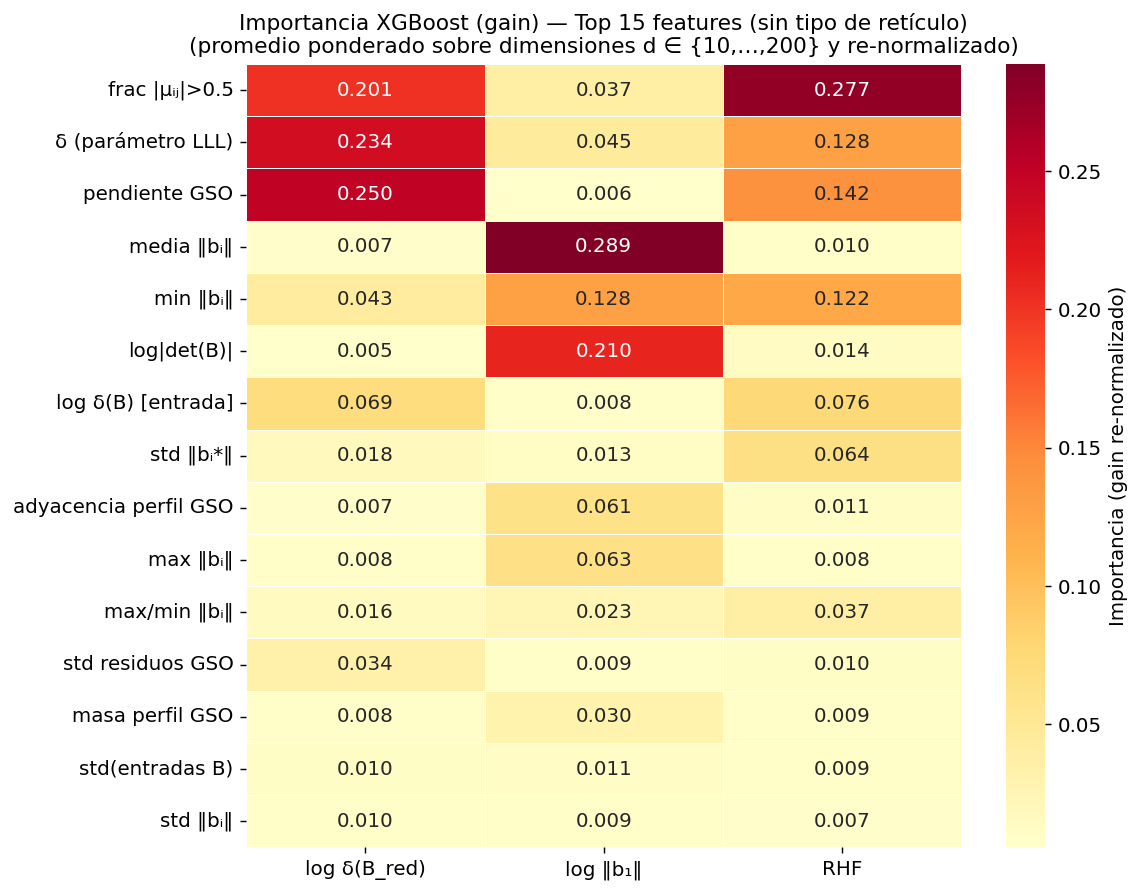

→ graphs/feat_importance_builtin_no_lt.png


In [4]:
# 1. Filtrar las features que no son de tipo de retículo
feat_no_lt_mask = [f not in lt_cols for f in FEAT_COLS_PER_DIM]
feat_no_lt_labels = [feat_labels_list[i] for i, m in enumerate(feat_no_lt_mask) if m]

# 2. Construir el DataFrame original filtrado
gain_no_lt_raw = pd.DataFrame(
    {TARGET_LABELS[t]: gain_importance[t][feat_no_lt_mask] for t in TARGETS},
    index=feat_no_lt_labels
)

# 3. RE-PONDERACIÓN: Dividir cada columna por su propia suma para que vuelvan a sumar 1.000
gain_no_lt = gain_no_lt_raw.div(gain_no_lt_raw.sum(axis=0), axis=1)

# 4. Seleccionar las Top 15 basadas en la nueva importancia relativa re-ponderada
top15_no_lt_idx = gain_no_lt.mean(axis=1).nlargest(15).index
gain_top_no_lt = gain_no_lt.loc[top15_no_lt_idx]

# 5. Graficar el heatmap
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    gain_top_no_lt, annot=True, fmt='.3f',
    cmap='YlOrRd', linewidths=0.4, ax=ax,
    cbar_kws={'label': 'Importancia (gain re-normalizado)'}
)
ax.set_title(
    'Importancia XGBoost (gain) — Top 15 features (sin tipo de retículo)\n'
    '(promedio ponderado sobre dimensiones d ∈ {10,…,200} y re-normalizado)'
)
plt.tight_layout()
plt.savefig('graphs/feat_importance_builtin_no_lt.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ graphs/feat_importance_builtin_no_lt.png')

---
## 2. Análisis SHAP — Importancia global por target

### Metodología

Para cada par (target, dimensión `d`):
1. Se carga el modelo XGBoost y el scaler correspondientes de `models/per_dim/`.
2. Se reconstruye el conjunto de test con la misma semilla (`random_state=42`, 20% del split).
3. Se submuestrea aleatoriamente a 300 ejemplos para agilizar el cálculo.
4. Se calcula la media del valor absoluto SHAP por feature: $\bar{\phi}_j = \frac{1}{n}\sum_i |\phi_j^{(i)}|$.

La importancia global se obtiene como **media ponderada** de $\bar{\phi}_j$ sobre todas las dimensiones,
con peso igual al tamaño del conjunto de test de cada dimensión.

La **entropía de Shannon** $H = -\sum_j p_j \log p_j$ (donde $p_j = \bar{\phi}_j / \sum_k \bar{\phi}_k$)
cuantifica la uniformidad de la distribución y permite contrastar H3: el RHF debería tener H más alto.

In [5]:
SHAP_SUBSAMPLE = 300  # muestras por (target, d)

shap_global  = {t: np.zeros(len(FEAT_COLS_PER_DIM)) for t in TARGETS}
shap_per_dim = {t: {} for t in TARGETS}
total_w_shap = {t: 0.0 for t in TARGETS}

test_ids_set = load_test_base_ids()

print("Calculando valores SHAP (puede tardar ~1-2 min)...")
for target in TARGETS:
    print(f"\n  Target: {target}")
    for d in DIMS:
        df_d  = df_enc[df_enc['d'] == d]
        X_all = df_d[FEAT_COLS_PER_DIM].values

        is_test_mask = df_d['base_id'].isin(test_ids_set).to_numpy()
        X_test = X_all[is_test_mask]

        model  = joblib.load(f'models/per_dim/gb_{target}_d{d}.pkl')
        scaler = joblib.load(f'models/per_dim/scaler_{target}_d{d}.pkl')
        X_scaled = scaler.transform(X_test)

        rng = np.random.default_rng(42)
        idx = rng.choice(len(X_scaled), size=min(SHAP_SUBSAMPLE, len(X_scaled)), replace=False)
        X_sub = X_scaled[idx]

        explainer = shap.TreeExplainer(model)
        shap_vals = explainer.shap_values(X_sub, check_additivity=False)

        mean_abs = np.abs(shap_vals).mean(axis=0)
        shap_per_dim[target][d] = mean_abs

        w = is_test_mask.sum()
        shap_global[target] += mean_abs * w
        total_w_shap[target] += w
        print(f"    d={d:>3}: top feature → '{feat_labels_list[np.argmax(mean_abs)]}'")

    shap_global[target] /= total_w_shap[target]

print("\n✓ Cálculo SHAP completado.")

Calculando valores SHAP (puede tardar ~1-2 min)...

  Target: target_log_orth_defect
    d= 10: top feature → 'δ (parámetro LLL)'
    d= 20: top feature → 'δ (parámetro LLL)'
    d= 30: top feature → 'δ (parámetro LLL)'
    d= 50: top feature → 'frac |μᵢⱼ|>0.5'
    d= 80: top feature → 'frac |μᵢⱼ|>0.5'
    d=100: top feature → 'frac |μᵢⱼ|>0.5'
    d=120: top feature → 'frac |μᵢⱼ|>0.5'
    d=150: top feature → 'frac |μᵢⱼ|>0.5'
    d=200: top feature → 'frac |μᵢⱼ|>0.5'

  Target: target_log_norm_b1
    d= 10: top feature → 'log|det(B)|'
    d= 20: top feature → 'δ (parámetro LLL)'
    d= 30: top feature → 'δ (parámetro LLL)'
    d= 50: top feature → 'δ (parámetro LLL)'
    d= 80: top feature → 'δ (parámetro LLL)'
    d=100: top feature → 'frac |μᵢⱼ|>0.5'
    d=120: top feature → 'frac |μᵢⱼ|>0.5'
    d=150: top feature → 'media ‖bᵢ‖'
    d=200: top feature → 'media ‖bᵢ‖'

  Target: target_rhf
    d= 10: top feature → 'δ (parámetro LLL)'
    d= 20: top feature → 'δ (parámetro LLL)'
    d= 

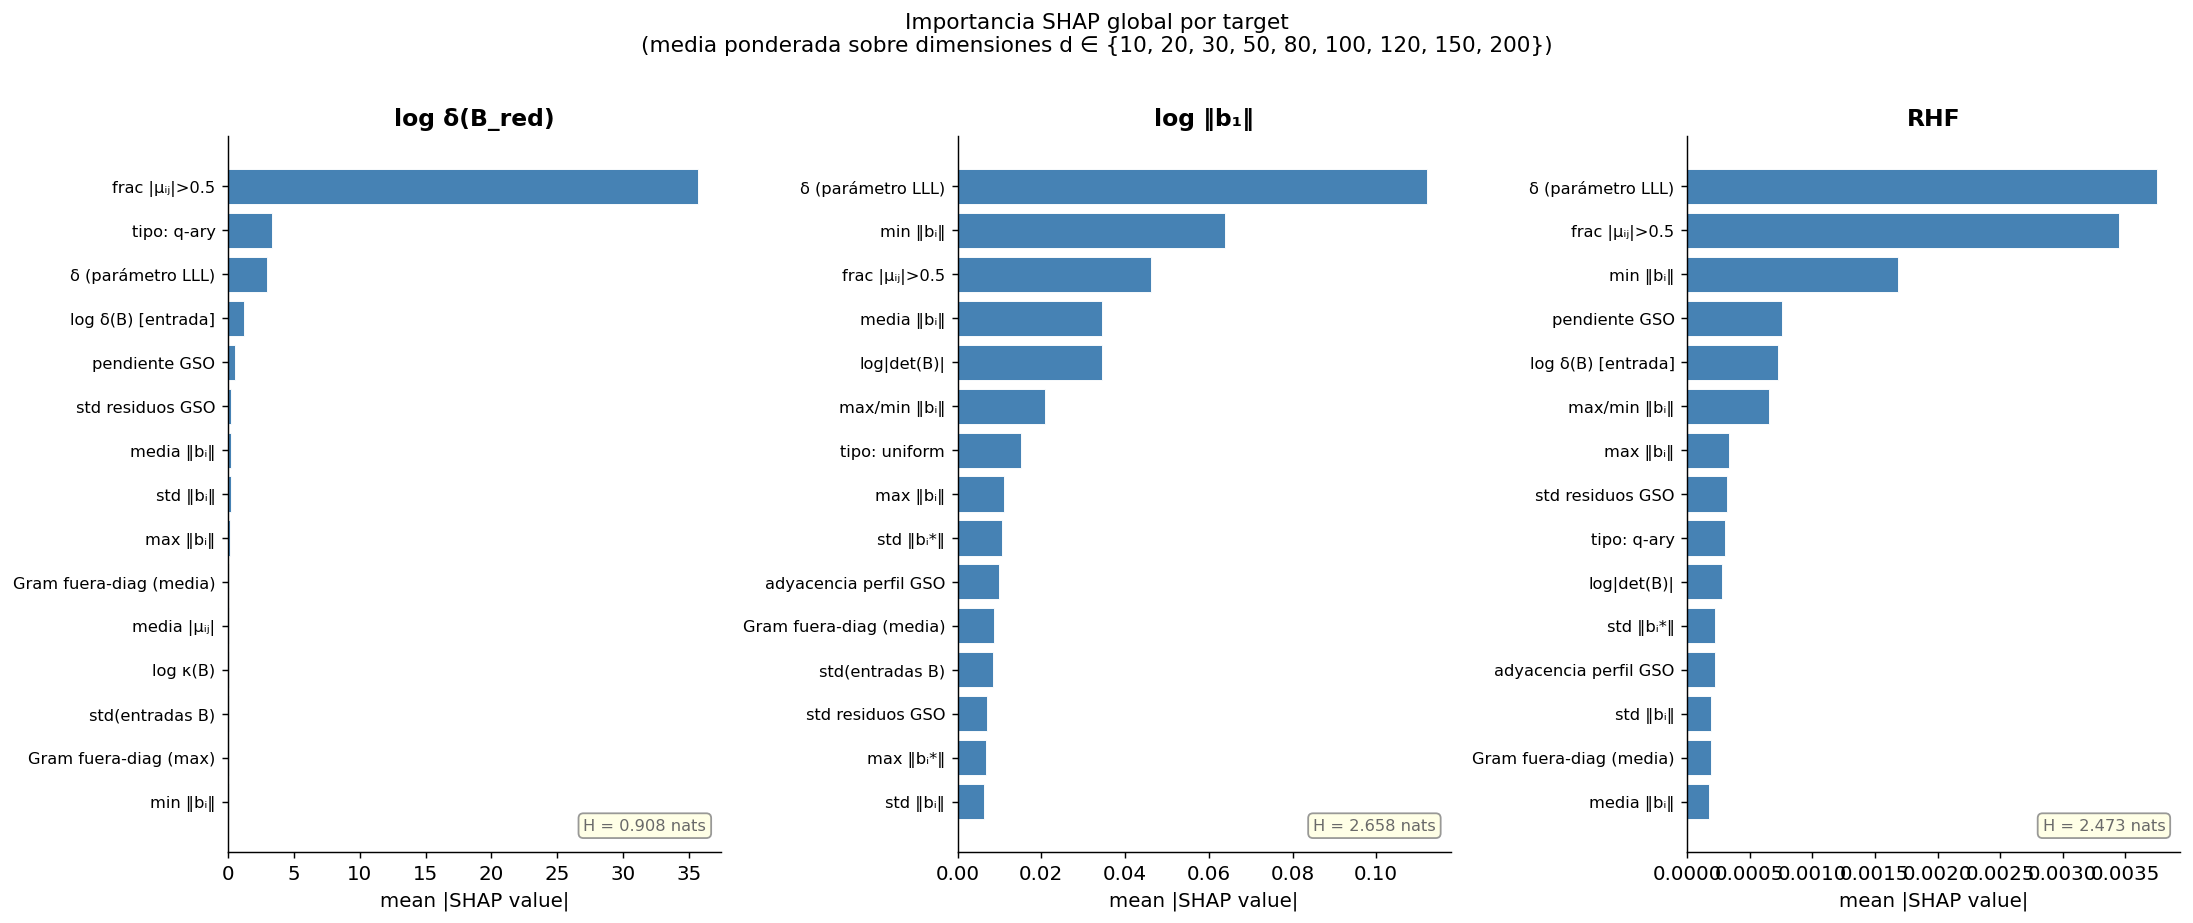

→ graphs/feat_importance_shap_global.png

Entropía de Shannon de la distribución SHAP (test H3):
  log δ(B_red)        : H = 0.9076 nats
  log ‖b₁‖            : H = 2.6576 nats
  RHF                 : H = 2.4731 nats
  (mayor H → distribución más uniforme → mayor dificultad de predicción)


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 7), sharey=False)
TOP_N = 15
entropies = {}

for ax, target in zip(axes, TARGETS):
    imp   = shap_global[target]
    order = np.argsort(imp)[::-1][:TOP_N]
    vals  = imp[order]
    names = [feat_labels_list[i] for i in order]

    ax.barh(names[::-1], vals[::-1], color='steelblue', edgecolor='white', linewidth=0.5)
    ax.set_title(TARGET_LABELS[target], fontweight='bold', fontsize=13)
    ax.set_xlabel('mean |SHAP value|')
    ax.tick_params(axis='y', labelsize=9)

    imp_norm = imp / imp.sum()
    H = scipy_entropy(imp_norm)
    entropies[target] = H
    ax.annotate(
        f'H = {H:.3f} nats',
        xy=(0.97, 0.03), xycoords='axes fraction',
        ha='right', fontsize=9, color='dimgray',
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='gray', alpha=0.8)
    )

plt.suptitle(
    'Importancia SHAP global por target\n'
    '(media ponderada sobre dimensiones d ∈ {10, 20, 30, 50, 80, 100, 120, 150, 200})',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig('graphs/feat_importance_shap_global.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ graphs/feat_importance_shap_global.png')

print("\nEntropía de Shannon de la distribución SHAP (test H3):")
for t, H in entropies.items():
    print(f"  {TARGET_LABELS[t]:<20}: H = {H:.4f} nats")
print("  (mayor H → distribución más uniforme → mayor dificultad de predicción)")

---
## 3. SHAP Beeswarm (d = 80) — Dirección de los efectos

Para la dimensión `d = 80` (régimen medio: R²_RHF ≈ 0.99, R²_defect ≈ 0.998) mostramos los
**beeswarm plots** de SHAP. Cada punto representa un ejemplo del test set:

- **Posición horizontal:** contribución de la feature a la predicción (derecha = aumenta el target predicho).
- **Color:** valor de la feature en escala original (rojo = valor alto, azul = valor bajo).

Esta visualización permite responder preguntas como:
- ¿Los valores **altos** de `log|det(B)|` aumentan o disminuyen `log ‖b₁‖` predicho?
- ¿Cómo actúa el parámetro `δ` (LLL) sobre el RHF predicho?

Para `target_log_norm_b1`, se espera que `log|det(B)|` sea la única barra amplia (H2).  
Para `target_rhf`, se espera que `δ` aparezca en el top y que los puntos sean más dispersos.

/tmp/ipykernel_34899/1699857613.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


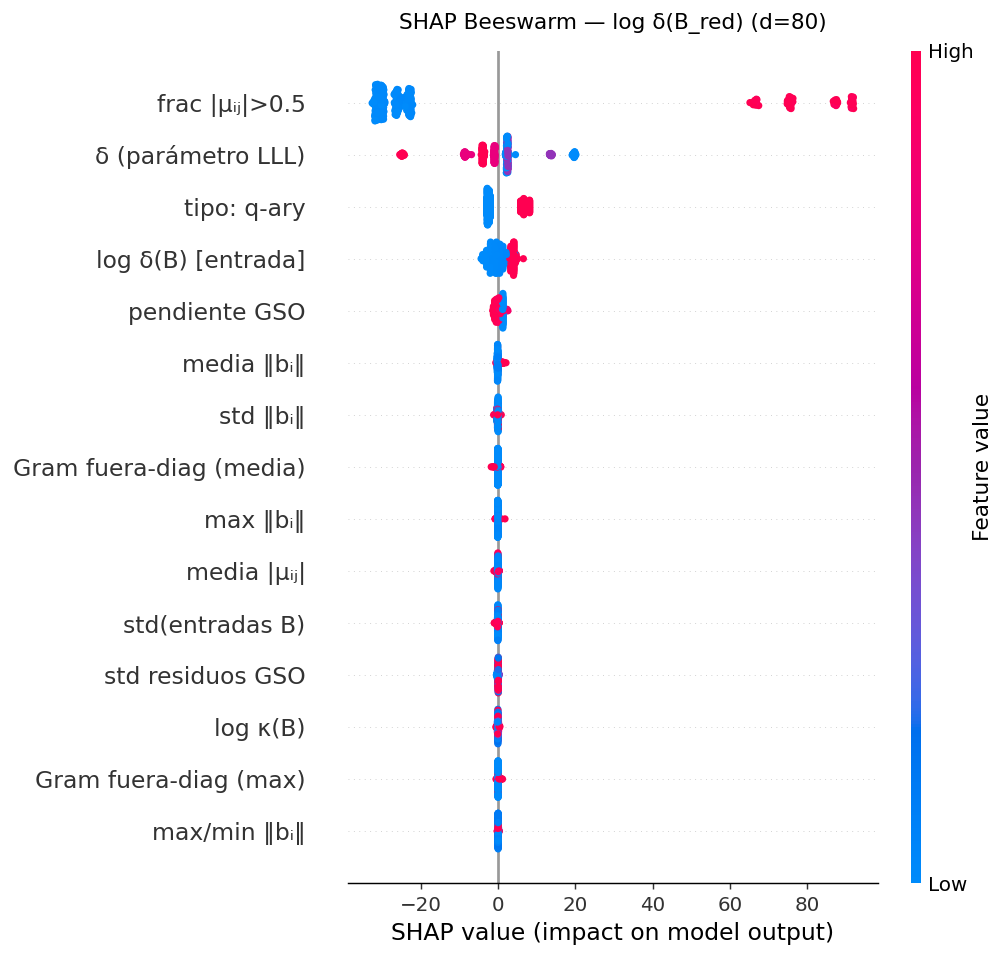

→ graphs/shap_beeswarm_log_orth_defect_d80.png


/tmp/ipykernel_34899/1699857613.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


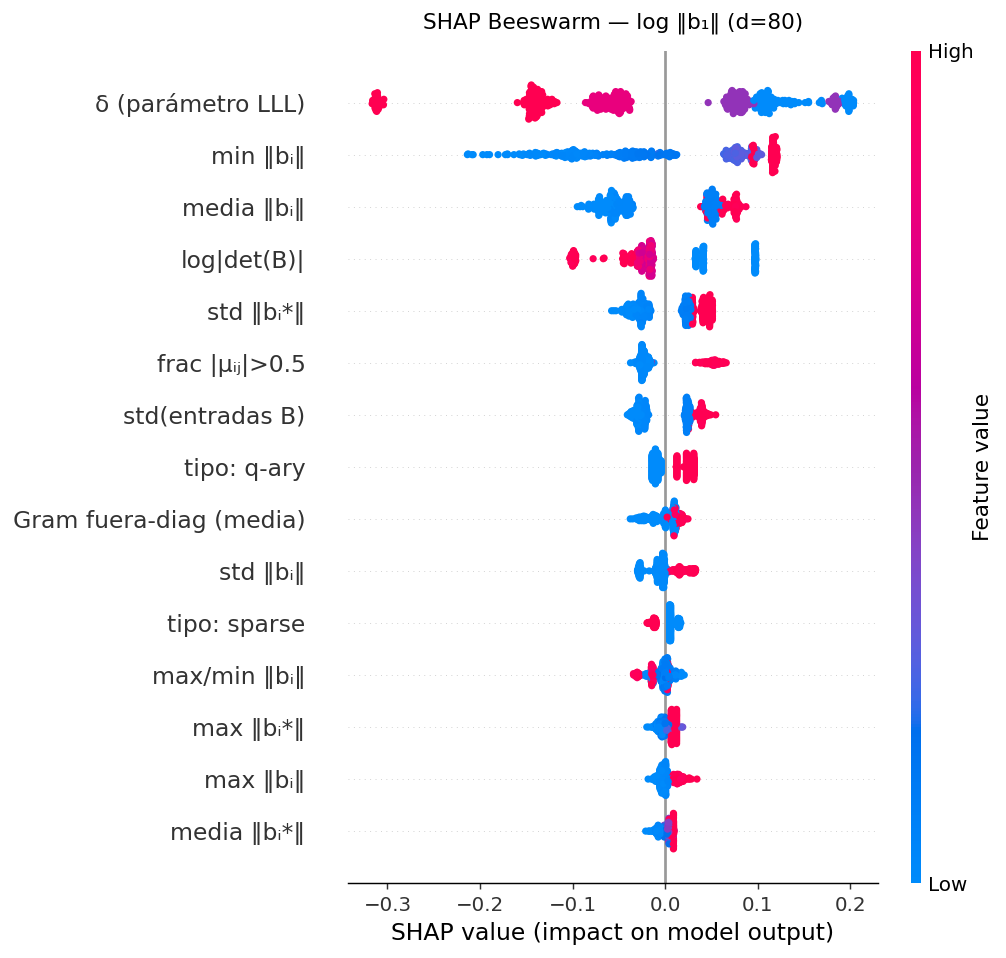

→ graphs/shap_beeswarm_log_norm_b1_d80.png


/tmp/ipykernel_34899/1699857613.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


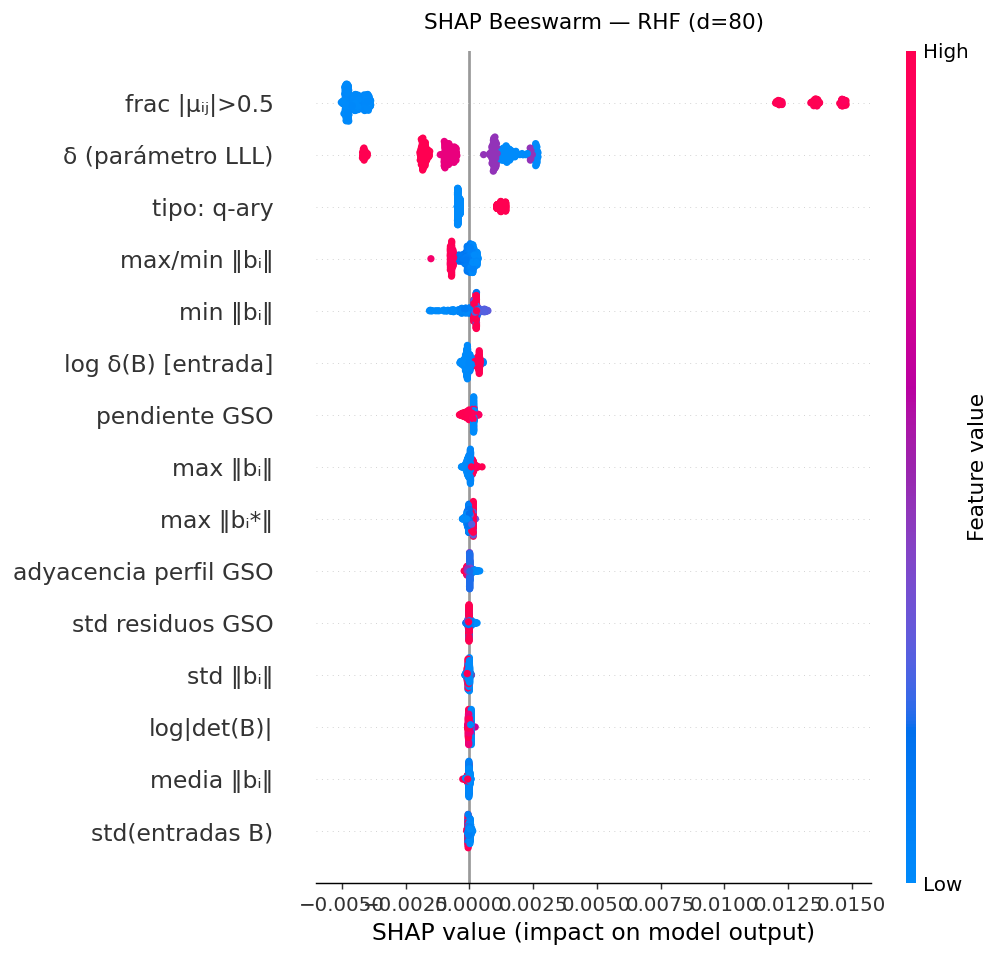

→ graphs/shap_beeswarm_rhf_d80.png


In [7]:
D_BEE      = 80
BEE_SAMPLE = 500

test_ids_set = load_test_base_ids()

for target in TARGETS:
    df_d  = df_enc[df_enc['d'] == D_BEE]
    X_all = df_d[FEAT_COLS_PER_DIM].values

    is_test_mask = df_d['base_id'].isin(test_ids_set).to_numpy()
    X_test = X_all[is_test_mask]

    model  = joblib.load(f'models/per_dim/gb_{target}_d{D_BEE}.pkl')
    scaler = joblib.load(f'models/per_dim/scaler_{target}_d{D_BEE}.pkl')
    X_scaled = scaler.transform(X_test)

    rng = np.random.default_rng(42)
    idx = rng.choice(len(X_scaled), size=min(BEE_SAMPLE, len(X_scaled)), replace=False)
    X_sub_scaled = X_scaled[idx]
    X_sub_orig   = X_test[idx]   # valores originales para colorear

    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_sub_scaled, check_additivity=False)

    target_short = target.replace('target_', '')
    fig_fname = f'graphs/shap_beeswarm_{target_short}_d{D_BEE}.png'

    shap.summary_plot(
        shap_vals, X_sub_orig,
        feature_names=feat_labels_list,
        max_display=15,
        show=False,
        plot_type='dot'
    )
    plt.title(f'SHAP Beeswarm — {TARGET_LABELS[target]} (d={D_BEE})', fontsize=12, pad=12)
    plt.tight_layout()
    plt.savefig(fig_fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'→ {fig_fname}')

---
## 4. Estabilidad de la importancia SHAP con la dimensión

Para las **top-8 features** de cada target (según importancia SHAP global) mostramos cómo evoluciona
la importancia media |SHAP| a lo largo de las dimensiones `d ∈ {10, 20, 30, 50, 80, 100, 120, 150, 200}`.

Esto permite detectar:
- Features que dominan **a todas las dimensiones** (propiedades geométricas universales del retículo).
- Features que sólo son relevantes a **dimensiones bajas** (donde el RHF aún no ha convergido al valor teórico de LLL ≈ 1.022).
- Si `δ` (parámetro LLL) gana o pierde importancia con la dimensión.

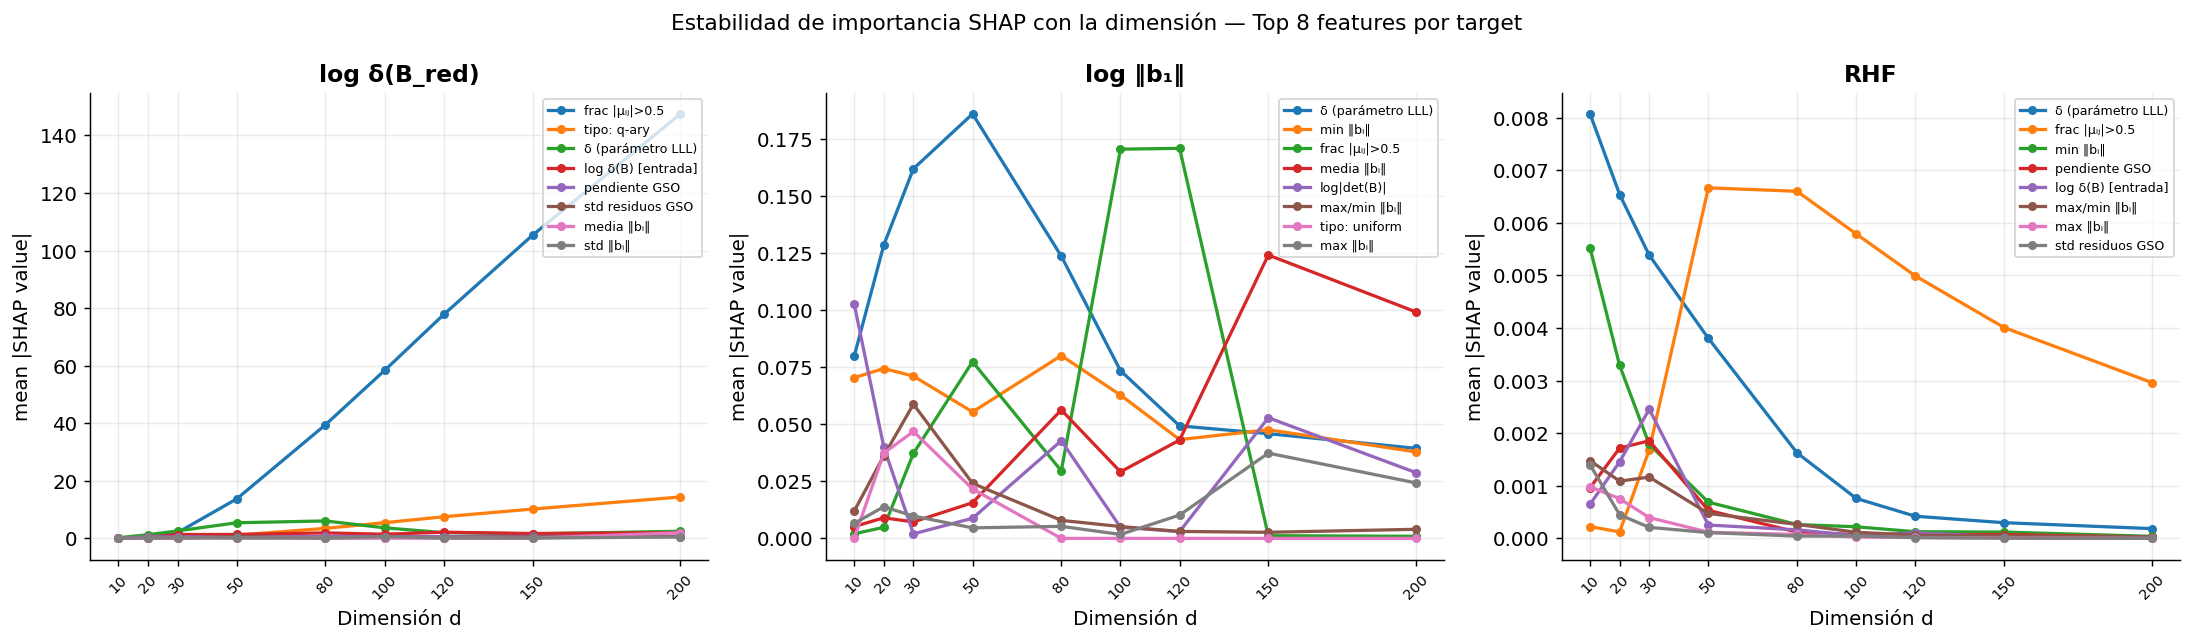

→ graphs/shap_stability.png


In [8]:
TOP_STABLE = 8
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=False)

for ax, target in zip(axes, TARGETS):
    order      = np.argsort(shap_global[target])[::-1][:TOP_STABLE]
    top_labels = [feat_labels_list[i] for i in order]

    for k, (feat_idx, name) in enumerate(zip(order, top_labels)):
        vals = [shap_per_dim[target][d][feat_idx] for d in DIMS]
        ax.plot(DIMS, vals, 'o-', label=name, color=colors[k % len(colors)],
                linewidth=1.8, markersize=4)

    ax.set_title(TARGET_LABELS[target], fontweight='bold', fontsize=13)
    ax.set_xlabel('Dimensión d')
    ax.set_ylabel('mean |SHAP value|')
    ax.set_xticks(DIMS)
    ax.set_xticklabels([str(d) for d in DIMS], rotation=45, fontsize=8)
    ax.legend(fontsize=7, loc='upper right', framealpha=0.8)
    ax.grid(True, alpha=0.25)

plt.suptitle(
    'Estabilidad de importancia SHAP con la dimensión — Top 8 features por target',
    fontsize=12
)
plt.tight_layout()
plt.savefig('graphs/shap_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ graphs/shap_stability.png')